In [78]:
%pip install scikit-learn
%pip install pandas
%pip install seaborn




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [79]:
import sys
print(sys.version)

3.12.1 (main, Mar 11 2026, 12:17:56) [GCC 13.3.0]


In [80]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [81]:
con = sqlite3.connect('ProjectData/gas_monitoring.db')

cursor = con.cursor()

        # Query the sqlite_master table to get table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        
        # Fetch all results
table_names = [row[0] for row in cursor.fetchall()]
query = "SELECT * FROM gas_monitoring"  # Replace 'your_table_name' with the actual table name
df = pd.read_sql_query(query, con)

^^"data ingestion" step, pull data and load into pandas data frame for later steps

CHECKING DATA

In [82]:
print(df.shape)
for cols in df:
    print(cols)

(10000, 14)
Time of Day
Temperature
Humidity
CO2_InfraredSensor
CO2_ElectroChemicalSensor
MetalOxideSensor_Unit1
MetalOxideSensor_Unit2
MetalOxideSensor_Unit3
MetalOxideSensor_Unit4
CO_GasSensor
Session ID
HVAC Operation Mode
Ambient Light Level
Activity Level


^^Table has 14 columns and 10000 rows

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  str    
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  str    
 12  Ambient Light Level        8946 non-null   str    
 13  Activity Level             10000 non-null  str    
dtypes:

^^
0. might have to standardise time of day 

1-10. Check numerics for outliers, maybe check if some readings correspond to celcius/farenheit counterpart

11-13. Make sure all modes make sense / can be turned into one-hot encode, needs futher exploration as well

In [85]:
for col in df.columns:
    print(f"--- Value Counts for {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
afternoon    2635
evening      2476
morning      2460
night        2429
Name: count, dtype: int64


--- Value Counts for Temperature ---
Temperature
19.460000     31
19.000000     30
19.480000     30
19.510000     26
19.450000     26
              ..
294.800000     1
27.989013      1
295.610000     1
295.670000     1
296.170000     1
Name: count, Length: 1796, dtype: int64


--- Value Counts for Humidity ---
Humidity
 52.23     18
 51.77     16
 52.91     15
 52.19     15
 52.36     15
           ..
 183.84     1
-11.60      1
-19.31      1
 120.33     1
 152.46     1
Name: count, Length: 2048, dtype: int64


--- Value Counts for CO2_InfraredSensor ---
CO2_InfraredSensor
97.651034     5
129.765286    5
134.468644    4
79.689878     4
102.762985    4
             ..
137.854649    1
131.945968    1
136.422868    1
126.734430    1
85.269262     1
Name: count, Length: 8899, dtype: int64


--- Value Counts for CO2_ElectroChemicalSensor ---
CO

^^
Only working with set time of day, no dates or exact timings 

definitely invalid values in temperature, over 100 values

negative values spoted for humidity

rounding to be done for numerics to reduce noise

GasSensor is nominal

Operation mode labels need cleaning, same for activity level
threshold values: temperature, humidity and sensors

In [86]:

df[df.duplicated()].shape


(171, 14)

Number of Duplicates: 171

In [87]:
df = pd.read_sql_query(query, con)
print(df[df.duplicated].describe())
df = df.drop_duplicates()
df = df.round(1)
print(df.shape)

       Temperature    Humidity  CO2_InfraredSensor  CO2_ElectroChemicalSensor  \
count   171.000000  160.000000          171.000000                 171.000000   
mean     20.687602   51.147313          110.794873                 578.506844   
std       2.285863    4.036007           20.333477                  22.469393   
min      16.020000   40.040000           60.765226                 538.680570   
25%      19.010000   48.570000          100.063105                 558.870792   
50%      20.240000   51.905000          113.652188                 579.956321   
75%      22.950000   53.915000          122.392189                 595.434243   
max      25.700000   58.580000          169.015970                 629.782780   

       MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  MetalOxideSensor_Unit3  \
count              171.000000              167.000000              171.000000   
mean               467.918070              727.102130              680.222884   
std                 49.8719

^^ removed duplicates to prevent data leakage for model and rounded values to simplify patterns

Checking GasSensor

In [88]:
for level, group in df.groupby('CO_GasSensor'):
    print(f"\n--- CO_GasSensor Level: {level} ---")
    print(group[['CO2_ElectroChemicalSensor', 'CO2_InfraredSensor']].describe())


--- CO_GasSensor Level: 0.0 ---
       CO2_ElectroChemicalSensor  CO2_InfraredSensor
count                1170.000000         1170.000000
mean                  603.958632           80.355897
std                    18.431779           34.116835
min                   555.000000          -14.500000
25%                   591.025000           65.700000
50%                   607.600000           74.450000
75%                   618.200000           85.600000
max                   637.900000          237.800000

--- CO_GasSensor Level: 1.0 ---
       CO2_ElectroChemicalSensor  CO2_InfraredSensor
count                4631.000000         4631.000000
mean                  579.793155          110.339883
std                    20.463388           31.661949
min                   535.000000          -17.400000
25%                   560.300000           99.800000
50%                   583.200000          112.200000
75%                   595.300000          122.500000
max                   631.700000 

^^As GasSensor level goes up, ElectroSensor reading decreases and Infrared increases, to be checked again after removing invalid values

In [89]:
print("number of rows with na: ", df.isna().sum().sum())
df.isna().sum()

number of rows with na:  5205


Time of Day                     0
Temperature                     0
Humidity                     1917
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1406
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  830
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1052
Activity Level                  0
dtype: int64

^^Humidity, Unit2, Light level, CO sensor have missing values with humidity having most and sensor having least


In [90]:
target_cols = ['Humidity', 'MetalOxideSensor_Unit2', 'Ambient Light Level', 'CO_GasSensor']

# 2. Count nulls across rows (axis=1) for just those columns, and filter for >= 2
df_filtered = df[df[target_cols].isnull().sum(axis=1) >= 2]

print(df_filtered.isna().sum())
print("")
print("number of rows with >1 na: ", df_filtered.isna().sum().sum())

Time of Day                    0
Temperature                    0
Humidity                     570
CO2_InfraredSensor             0
CO2_ElectroChemicalSensor      0
MetalOxideSensor_Unit1         0
MetalOxideSensor_Unit2       480
MetalOxideSensor_Unit3         0
MetalOxideSensor_Unit4         0
CO_GasSensor                 295
Session ID                     0
HVAC Operation Mode            0
Ambient Light Level          370
Activity Level                 0
dtype: int64

number of rows with >1 na:  1715


^^Out of the 5205 rows with error, most only have a single one null value

STANDARDISATION

In [91]:
df_standard = df.copy()
df_standard["HVAC Operation Mode"] = df_standard["HVAC Operation Mode"].str.lower().str.replace(" ", "_")
df_standard["Activity Level"] = df_standard["Activity Level"].str.replace(" ", "").str.replace("_", "")

non_numeric_cols = df_standard.select_dtypes(exclude=["number"]).columns
for col in non_numeric_cols:
    print(f"--- Value Counts for {col} ---")
    print(df_standard[col].value_counts(dropna=False))
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
afternoon    2586
evening      2432
morning      2415
night        2396
Name: count, dtype: int64


--- Value Counts for HVAC Operation Mode ---
HVAC Operation Mode
cooling_active      1700
maintenance_mode    1670
eco_mode            1643
heating_active      1631
off                 1630
ventilation_only    1555
Name: count, dtype: int64


--- Value Counts for Ambient Light Level ---
Ambient Light Level
very_bright    3317
bright         2655
moderate       1429
NaN            1052
dim             852
very_dim        524
Name: count, dtype: int64


--- Value Counts for Activity Level ---
Activity Level
LowActivity         5669
ModerateActivity    3090
HighActivity        1070
Name: count, dtype: int64




^^ Ensured consistent format within columns

Checking nan rows to check if sensors are failing together

In [92]:
df_nan = df_standard[df_standard.isna().any(axis=1)].copy()
rows_with_1_nan = df_nan[df_nan.isnull().sum(axis=1) == 1]
rows_with_2_nan = df_nan[df_nan.isnull().sum(axis=1) == 2]
rows_with_3_nan = df_nan[df_nan.isnull().sum(axis=1) == 3]
rows_with_4_nan = df_nan[df_nan.isnull().sum(axis=1) == 4]

print("1nan:", rows_with_1_nan.shape) 
print("2nan:", rows_with_2_nan.shape)
print("3nan:", rows_with_3_nan.shape)
print("4nan:", rows_with_4_nan.shape)  


1nan: (3490, 14)
2nan: (749, 14)
3nan: (67, 14)
4nan: (4, 14)


In [93]:
rows_with_2_nan.isnull().describe()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
count,749,749,749,749,749,749,749,749,749,749,749,749,749,749
unique,1,1,2,1,1,1,2,1,1,2,1,1,2,1
top,False,False,True,False,False,False,True,False,False,False,False,False,False,False
freq,749,749,510,749,749,749,422,749,749,498,749,749,434,749


^^ Sensors seem to be failling together coincidentally

Label encode for model

In [94]:
string_cols = df_standard.select_dtypes(include=['str', 'category']).columns
for col in string_cols:
    print(col)

Time of Day
HVAC Operation Mode
Ambient Light Level
Activity Level


In [95]:
custom_orders = {
    'Time of Day': ['morning', 'afternoon', 'evening', 'night'],
    'Activity Level': ['LowActivity','ModerateActivity','HighActivity'],
    'Ambient Light Level': ['very_dim','dim','moderate','bright','very_bright']
}

legend_data = []

for col in string_cols:
    if col in custom_orders:
        ordered_vals = custom_orders[col]
        # Ensure all existing values are in the order list (or handle missing)
        mapping = {val: idx+1 for idx, val in enumerate(ordered_vals)}
    else:
        # Fallback to alphabetical
        unique_values = sorted(df_standard[col].dropna().unique())
        mapping = {val: idx+1 for idx, val in enumerate(unique_values)}
    
    df_standard[col] = df_standard[col].map(mapping)
    
    for val, code in mapping.items():
        legend_data.append({
            "Column": col,
            "Original_Value": val,
            "Encoded_Value": code
        })

df_legend = pd.DataFrame(legend_data)

# 3. View results
print("--- ENCODED DATAFRAME SAMPLE ---")
print(df_standard.head())

print("\n--- REFERENCE LEGEND ---")
print(df_legend)

--- ENCODED DATAFRAME SAMPLE ---
   Time of Day  Temperature  Humidity  CO2_InfraredSensor  \
0            1         19.6      53.8               125.5   
1            1        292.8      53.7               126.3   
2            1         19.6      54.2               126.6   
3            1         20.1      50.5               113.5   
4            1         19.9      48.4                92.8   

   CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  \
0                      571.1                   478.6                   735.9   
1                      575.8                   492.0                   740.3   
2                      585.5                   505.6                   737.1   
3                      597.4                   515.1                   744.0   
4                      613.7                   535.7                   770.3   

   MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor  Session ID  \
0                   654.6               

^^ ensure all were ordinal values except for hvac which was nominal

In [96]:
string_cols = df_standard.select_dtypes(include=['str', 'category']).columns
for col in string_cols:
    print(col)

^^ Ensuring no str value

Linear Correlation of Nulls

In [97]:
df_standard.shape

(9829, 14)

In [98]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['Humidity_is_missing'] = df_check['Humidity'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['Humidity_is_missing'])
print(df_check['Humidity'].isnull().sum())

Time of Day                 -0.013880
Temperature                  0.000724
Humidity                          NaN
CO2_InfraredSensor          -0.005362
CO2_ElectroChemicalSensor   -0.000884
MetalOxideSensor_Unit1       0.007611
MetalOxideSensor_Unit2      -0.003758
MetalOxideSensor_Unit3       0.005339
MetalOxideSensor_Unit4       0.002014
CO_GasSensor                -0.012839
Session ID                   0.001223
HVAC Operation Mode         -0.011275
Ambient Light Level         -0.007529
Activity Level              -0.009033
Humidity_is_missing          1.000000
Name: Humidity_is_missing, dtype: float64
1917


In [99]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['CO_is_missing'] = df_check['CO_GasSensor'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['CO_is_missing'])
print(df_check['CO_GasSensor'].isnull().sum())

Time of Day                 -0.000030
Temperature                  0.006782
Humidity                    -0.004094
CO2_InfraredSensor           0.007561
CO2_ElectroChemicalSensor   -0.002406
MetalOxideSensor_Unit1      -0.000770
MetalOxideSensor_Unit2      -0.011541
MetalOxideSensor_Unit3      -0.018714
MetalOxideSensor_Unit4      -0.007975
CO_GasSensor                      NaN
Session ID                  -0.002967
HVAC Operation Mode          0.021182
Ambient Light Level          0.005888
Activity Level              -0.005700
CO_is_missing                1.000000
Name: CO_is_missing, dtype: float64
830


In [100]:
df_check = df_standard.copy()
df_check['MetalOxideSensor_Unit2_is_missing'] = df_check['MetalOxideSensor_Unit2'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['MetalOxideSensor_Unit2_is_missing'])
print(df_check['MetalOxideSensor_Unit2'].isnull().sum())

Time of Day                         -0.004695
Temperature                          0.005052
Humidity                             0.010955
CO2_InfraredSensor                   0.000150
CO2_ElectroChemicalSensor            0.013767
MetalOxideSensor_Unit1               0.008170
MetalOxideSensor_Unit2                    NaN
MetalOxideSensor_Unit3              -0.002977
MetalOxideSensor_Unit4               0.003050
CO_GasSensor                        -0.007952
Session ID                           0.010441
HVAC Operation Mode                  0.004410
Ambient Light Level                  0.012752
Activity Level                       0.003773
MetalOxideSensor_Unit2_is_missing    1.000000
Name: MetalOxideSensor_Unit2_is_missing, dtype: float64
1406


In [101]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['Light_is_missing'] = df_check['Ambient Light Level'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['Light_is_missing'])
print(df_check['Ambient Light Level'].isnull().sum())

Time of Day                 -0.015648
Temperature                 -0.011524
Humidity                    -0.007032
CO2_InfraredSensor          -0.015743
CO2_ElectroChemicalSensor   -0.004018
MetalOxideSensor_Unit1       0.016216
MetalOxideSensor_Unit2       0.011662
MetalOxideSensor_Unit3       0.009585
MetalOxideSensor_Unit4       0.008843
CO_GasSensor                -0.004052
Session ID                   0.009631
HVAC Operation Mode         -0.001778
Ambient Light Level               NaN
Activity Level               0.019863
Light_is_missing             1.000000
Name: Light_is_missing, dtype: float64
1052


^^No linear correllation found with null values, not caused by recorded environmental variables

INVALID VALUES

In [102]:
numeric_cols = df_standard.select_dtypes(exclude=["str"]).columns
for col in numeric_cols:
    print(f"--- Value Counts for {col} ---")
    print(df_standard[col].value_counts(dropna=False))
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
2    2586
3    2432
1    2415
4    2396
Name: count, dtype: int64


--- Value Counts for Temperature ---
Temperature
19.0     225
19.5     196
18.8     184
19.6     180
18.9     179
        ... 
32.4       1
33.6       1
27.8       1
30.8       1
280.4      1
Name: count, Length: 349, dtype: int64


--- Value Counts for Humidity ---
Humidity
 NaN      1917
 52.2      120
 51.8      103
 52.6      103
 53.2       96
          ... 
 150.7       1
 183.8       1
-19.3        1
 120.3       1
 152.5       1
Name: count, Length: 557, dtype: int64


--- Value Counts for CO2_InfraredSensor ---
CO2_InfraredSensor
 119.1    35
 111.0    35
 113.6    34
 113.9    32
 109.5    32
          ..
 54.4      1
 180.2     1
 214.8     1
 200.5     1
-15.0      1
Name: count, Length: 1602, dtype: int64


--- Value Counts for CO2_ElectroChemicalSensor ---
CO2_ElectroChemicalSensor
550.4    28
550.9    27
549.3    26
599.5    25
586.3    25
         ..
534.

In [103]:
numeric_cols = df_standard.select_dtypes(exclude=["str"]).columns
for col in numeric_cols:
    print(f"--- Value Counts for {col} ---")
    print(df_standard[col].describe(percentiles=None, include=None, exclude=None))
    print("\n")

--- Value Counts for Time of Day ---
count    9829.000000
mean        2.489266
std         1.108580
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: Time of Day, dtype: float64


--- Value Counts for Temperature ---
count    9829.000000
mean       42.618293
std        74.560291
min         6.900000
25%        18.900000
50%        20.500000
75%        23.200000
max       307.100000
Name: Temperature, dtype: float64


--- Value Counts for Humidity ---
count    7912.000000
mean       51.653716
std        21.540630
min       -49.900000
25%        47.600000
50%        51.400000
75%        53.800000
max       198.900000
Name: Humidity, dtype: float64


--- Value Counts for CO2_InfraredSensor ---
count    9829.000000
mean      109.848621
std        33.981282
min       -17.500000
25%        96.500000
50%       112.800000
75%       124.600000
max       237.900000
Name: CO2_InfraredSensor, dtype: float64


--- Value Counts for CO2_Ele

In [104]:
df_OxideSensors = pd.DataFrame(pd.concat([
    df_standard["MetalOxideSensor_Unit1"],
    df_standard["MetalOxideSensor_Unit2"],
    df_standard["MetalOxideSensor_Unit3"],
    df_standard["MetalOxideSensor_Unit4"]
], ignore_index=True))
df_OxideSensors.columns = ['Combined_MetalOxide_Readings']
df_OxideSensors.describe(percentiles=None, include=None, exclude=None)

,Combined_MetalOxide_Readings
count,37910.000000
mean,619.124946
std,107.280528
min,286.800000
25%,538.900000
50%,641.500000
75%,704.900000
max,906.200000


Temperature is taken as celcius as more values are invalid if in farenheit

Humidity should be bounded between 0–100%

co2 infared and electro sensors min 0ppm     https://www.co2meter.com/en-sg/blogs/news/carbon-dioxide-indoor-levels-chart

Co2 GasSensor is in levels

HANDLING INVALID VALUES

In [105]:
# Create the mask
mask = (df_standard['Temperature'].between(0, 60) &
        df_standard['Humidity'].between(0, 100) &
        (df_standard['CO2_InfraredSensor'] >= 0) &
        (df_standard['CO2_ElectroChemicalSensor'] >= 0))

# Keep the rows that satisfy the conditions
df_included = df_standard[mask]

# Get the excluded rows (those that do NOT satisfy the conditions)
mask = (df_standard['Temperature'].between(0, 60))
df_excluded_temp = df_standard[~mask].copy()

mask = (df_standard['Humidity'].between(0, 100))
df_excluded_humidity = df_standard[~mask].copy()

mask = ((df_standard['CO2_InfraredSensor'] >= 0))
df_excluded_infrared = df_standard[~mask].copy()

mask = ((df_standard['CO2_ElectroChemicalSensor'] >= 0))
df_excluded_electro = df_standard[~mask].copy()


Viewing invalid values

In [106]:

print(df_excluded_temp['Temperature'].describe())
print('')
print(df_excluded_humidity['Humidity'].describe())
print('')

print(df_excluded_infrared['CO2_InfraredSensor'].describe())
print('')
print(df_excluded_electro['CO2_ElectroChemicalSensor'].describe())
print('')

count    795.000000
mean     293.762138
std        2.789218
min      280.400000
25%      291.900000
50%      293.400000
75%      295.900000
max      307.100000
Name: Temperature, dtype: float64

count    414.000000
mean      65.798551
std       91.599906
min      -49.900000
25%      -22.000000
50%       49.950000
75%      154.075000
max      198.900000
Name: Humidity, dtype: float64

count    112.000000
mean      -8.459821
std        5.009099
min      -17.500000
25%      -12.500000
50%       -8.200000
75%       -3.975000
max       -0.100000
Name: CO2_InfraredSensor, dtype: float64

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: CO2_ElectroChemicalSensor, dtype: float64



Humidity has large std, view in more detail

In [107]:
print(df_included['Humidity'].describe())
print('')
print("","vs","")
print('')
print(df_excluded_humidity.loc[df_excluded_humidity['Humidity'] > 100, 'Humidity'].describe())
print('')
print('')
print(df_excluded_humidity.loc[df_excluded_humidity['Humidity'] < 0, 'Humidity'].describe())

count    6818.000000
mean       50.908844
std         3.963127
min        39.700000
25%        48.000000
50%        51.400000
75%        53.700000
max        59.700000
Name: Humidity, dtype: float64

 vs 

count    207.000000
mean     154.670048
std       27.303246
min      101.300000
25%      131.300000
50%      154.100000
75%      179.900000
max      198.900000
Name: Humidity, dtype: float64


count    207.000000
mean     -23.072947
std       14.261199
min      -49.900000
25%      -35.700000
50%      -22.200000
75%      -10.950000
max       -1.400000
Name: Humidity, dtype: float64


In [108]:
print(df_included['Humidity'].describe())
print('')
print(df_excluded_humidity['Humidity'].describe())

count    6818.000000
mean       50.908844
std         3.963127
min        39.700000
25%        48.000000
50%        51.400000
75%        53.700000
max        59.700000
Name: Humidity, dtype: float64

count    414.000000
mean      65.798551
std       91.599906
min      -49.900000
25%      -22.000000
50%       49.950000
75%      154.075000
max      198.900000
Name: Humidity, dtype: float64


In [109]:
# Combine the two series, aligning by index, dropping duplicate indices
combined_df = pd.DataFrame({
    'Humidity': df_excluded_humidity['Humidity'],
    'CO2_InfraredSensor': df_excluded_infrared['CO2_InfraredSensor']
}).drop_duplicates()

# Now combined_df has rows that are the union, with only those two columns
print(len(combined_df) / len(df_standard) * 100)

4.517244887577577


Invalid temp is 10x of standard values, no other deviations

Invalid humidity data don’t show a simple symmetry, droping

Drop negative infrared values as less than 5%, no found pattern

In [110]:
df_excluded_temp['Temperature'] = df_excluded_temp['Temperature']/10
print(df_excluded_temp['Temperature'].describe())
print('')


count    795.000000
mean      29.376214
std        0.278922
min       28.040000
25%       29.190000
50%       29.340000
75%       29.590000
max       30.710000
Name: Temperature, dtype: float64



In [111]:
# Original masks
mask_humidity_bad = ~df_standard['Humidity'].between(0, 100)
mask_co2_bad = df_standard['CO2_InfraredSensor'] < 0
mask_combined = mask_humidity_bad | mask_co2_bad

# DataFrame with only the rows you want to keep
df_before = df_standard
df_standard = df_standard[~mask_combined].copy()
df_standard.loc[df_standard['Temperature'] > 100, 'Temperature']*=0.1

print(f"Before: {len(df_before)}")
print(f"Cleaned: {len(df_standard)}")
print(f"Dropped: {len(df_before) - len(df_standard)}")

Before: 9829
Cleaned: 7409
Dropped: 2420


HANDLING NAN values

In [112]:
print(df_standard.shape)
print("Nulls:")
print(df_standard.isnull().sum())
print("total null:", df_standard.isnull().sum().sum())

(7409, 14)
Nulls:
Time of Day                     0
Temperature                     0
Humidity                        0
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1057
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  627
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level           799
Activity Level                  0
dtype: int64
total null: 2483


In [113]:

print(df_standard.isnull().mean() * 100)

Time of Day                   0.000000
Temperature                   0.000000
Humidity                      0.000000
CO2_InfraredSensor            0.000000
CO2_ElectroChemicalSensor     0.000000
MetalOxideSensor_Unit1        0.000000
MetalOxideSensor_Unit2       14.266433
MetalOxideSensor_Unit3        0.000000
MetalOxideSensor_Unit4        0.000000
CO_GasSensor                  8.462681
Session ID                    0.000000
HVAC Operation Mode           0.000000
Ambient Light Level          10.784181
Activity Level                0.000000
dtype: float64


Imputation

median by subgroup based on time of day as sensor reading can be affected by daylight

In [114]:

df_standard['Ambient Light Level'] = df_standard.groupby('Time of Day')['Ambient Light Level'].transform(lambda x: x.fillna(x.median()))

KNN

KNN is used as environmental sensors operate together, sharing reaction to changes, having relation to one another

In [115]:
from sklearn.impute import KNNImputer 
from sklearn.preprocessing import MinMaxScaler
features = [
    'Temperature',
    'Humidity',
    'CO2_InfraredSensor',
    'CO2_ElectroChemicalSensor',
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4'
]

imputer = KNNImputer(n_neighbors=7)

df_standard[features] = imputer.fit_transform(
    df_standard[features]
)

In [116]:
df_standard['MetalOxideSensor_Unit2'].value_counts().value_counts()

count
1     1163
2      230
3      146
4      121
5      103
7       82
6       79
8       76
10      54
9       53
11      37
12      33
13      22
14      15
15       7
18       4
17       3
16       3
19       2
22       1
21       1
20       1
Name: count, dtype: int64

In [117]:
for cols in df_standard:
    print(cols)

Time of Day
Temperature
Humidity
CO2_InfraredSensor
CO2_ElectroChemicalSensor
MetalOxideSensor_Unit1
MetalOxideSensor_Unit2
MetalOxideSensor_Unit3
MetalOxideSensor_Unit4
CO_GasSensor
Session ID
HVAC Operation Mode
Ambient Light Level
Activity Level


In [118]:
df_standard['CO_GasSensor'].value_counts()

CO_GasSensor
1.0    3492
2.0    2031
0.0     871
3.0     334
4.0      54
Name: count, dtype: int64

In [119]:
print(f"NaNs remaining: {df_standard['CO_GasSensor'].isna().sum()}")

NaNs remaining: 627


In [120]:
from sklearn.impute import KNNImputer 
from sklearn.preprocessing import MinMaxScaler
features = [
    'Temperature',
    'Humidity',
    'CO2_InfraredSensor',
    'CO2_ElectroChemicalSensor',
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4',
    'CO_GasSensor'
]

imputer = KNNImputer(n_neighbors=1)

df_standard[features] = imputer.fit_transform(
    df_standard[features]
)

Value count 1 ensures that CO_GasSensor only imputes existing values for nan due to the categorical nature of data

In [121]:
df_standard['CO_GasSensor'].value_counts()


CO_GasSensor
1.0    3823
2.0    2197
0.0     954
3.0     371
4.0      64
Name: count, dtype: int64

Outliers

In [122]:
import pandas as pd
df_clean = df_standard

# (If it has timestamps/text, select_dtypes ensures it only checks numbers)
numeric_df = df_clean.select_dtypes(include=['number'])

# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Determine boundaries (1.5 is the standard IQR multiplier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Create a boolean mask where True indicates an outlier
outliers_mask = (numeric_df < lower_bound) | (numeric_df > upper_bound)

# 5. Summarize the results
outlier_counts = outliers_mask.sum()
outlier_percentages = (outlier_counts / len(df_clean)) * 100

# Combine everything into a clean summary table
iqr_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Percentage (%)': outlier_percentages.round(2),
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound
})

print("=== IQR Outlier Summary ===")
print(iqr_summary.sort_values(by='Outlier Count', ascending=False))

=== IQR Outlier Summary ===
                           Outlier Count  Percentage (%)  Lower Bound  \
MetalOxideSensor_Unit3               596            8.04        590.5   
CO2_InfraredSensor                   540            7.29         56.9   
MetalOxideSensor_Unit1               435            5.87        358.2   
Temperature                          349            4.71         12.7   
MetalOxideSensor_Unit4               249            3.36        511.6   
MetalOxideSensor_Unit2               125            1.69        656.6   
CO_GasSensor                          64            0.86         -0.5   
CO2_ElectroChemicalSensor              5            0.07        505.4   
Humidity                               0            0.00         39.2   
Time of Day                            0            0.00          0.5   
Session ID                             0            0.00      -3407.5   
HVAC Operation Mode                    0            0.00         -2.5   
Ambient Light Level    

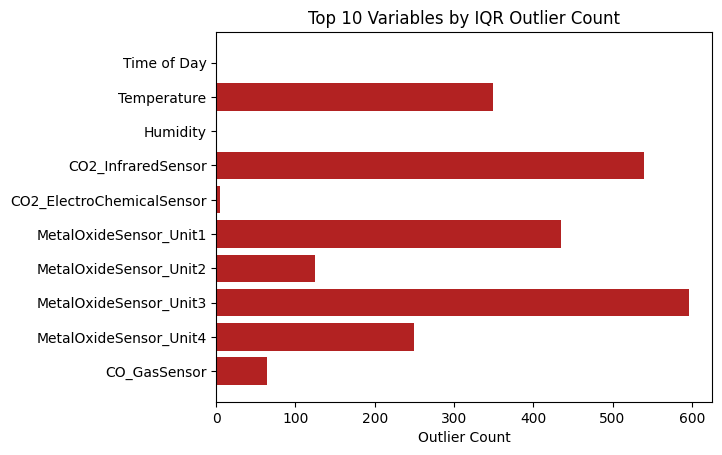

In [123]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df_summary is your table
top10 = iqr_summary.head(10)
plt.barh(top10.index, top10['Outlier Count'], color='firebrick')
plt.xlabel('Outlier Count')
plt.title('Top 10 Variables by IQR Outlier Count')
plt.gca().invert_yaxis()  # highest first
plt.show()

MO3 has most extreme spikes, data might be heavily skewed, same for infrared

CO_Gas and Electro likely have true anomalies due to low percentage.

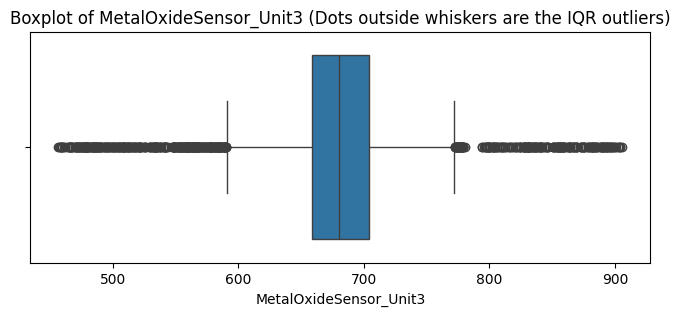

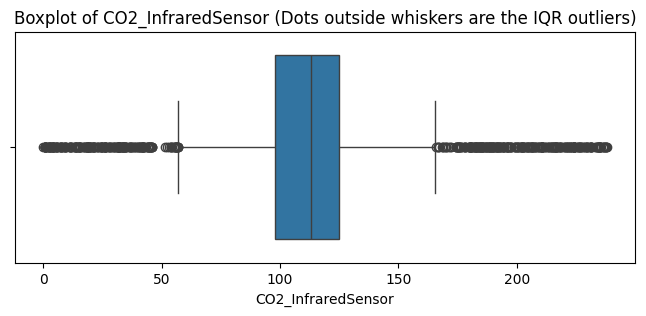

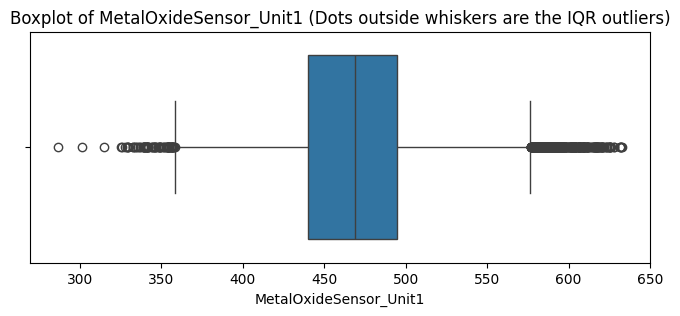

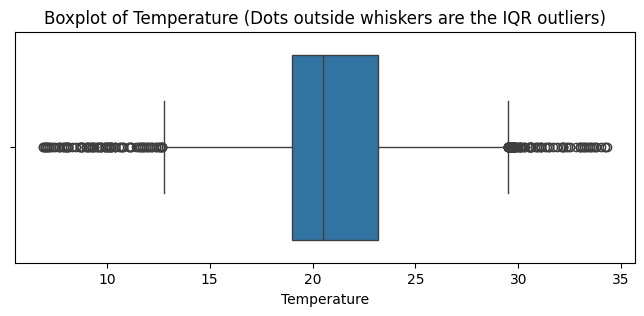

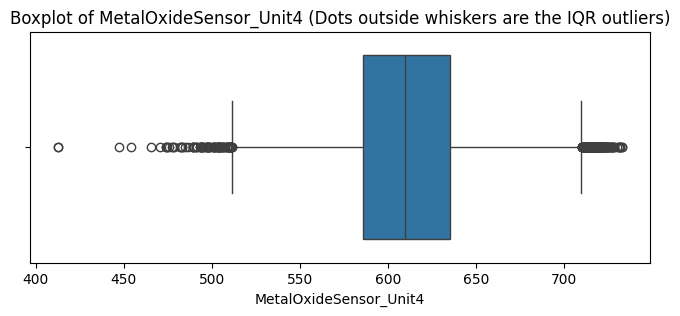

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Change column name to whatever showed the highest outlier count
top_outlier_col = iqr_summary.sort_values(by='Outlier Count', ascending=False).index[0]
for x in range(5):
    outlier_col = iqr_summary.sort_values(by='Outlier Count', ascending=False).index[x]
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_clean[outlier_col])
    plt.title(f"Boxplot of {outlier_col} (Dots outside whiskers are the IQR outliers)")
    plt.show()

MO3 has most outliers but the even spread, a heavy tail, occuring regularly, natural fluctuations

Infrared and temperature as well

MO1 and MO4 have some outliers spread further than others, suggesting true anomalies

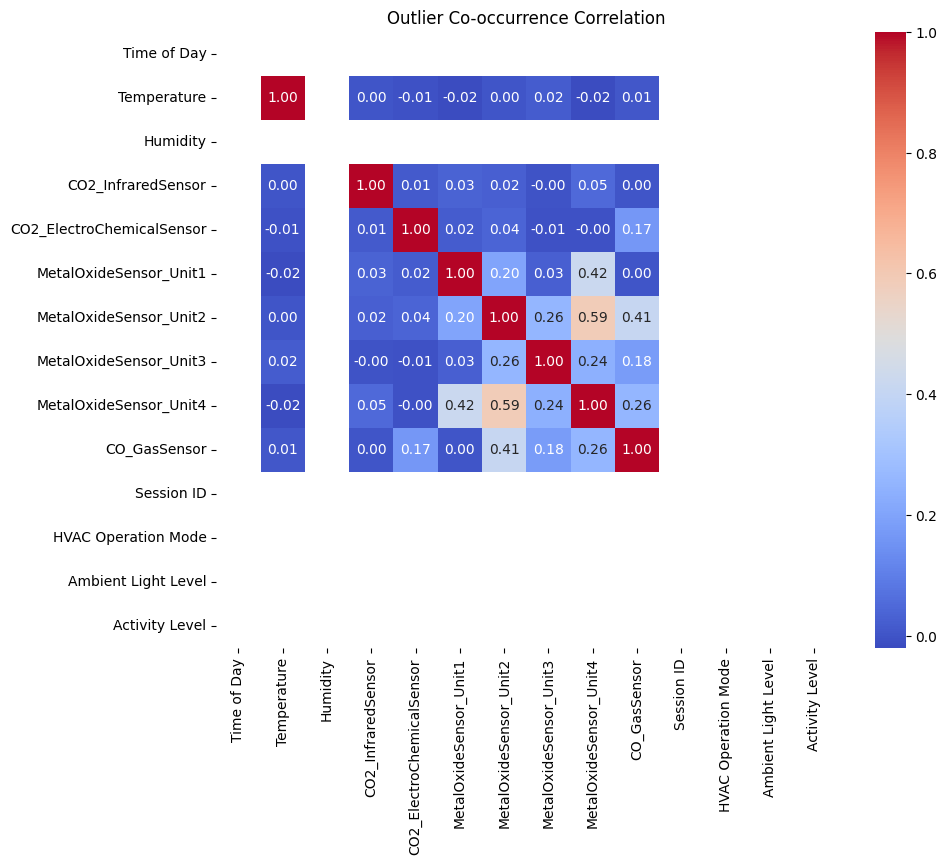

In [125]:


plt.figure(figsize=(10, 8))
sns.heatmap(outliers_mask.astype(int).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Outlier Co-occurrence Correlation')
plt.show()

True Outliers vs. Heavy Tails

the 'outliers' are natural and are intense spikes that happened naturally / caused by something

CHECKING CO2_GAS

In [126]:
for level, group in df_clean.groupby('CO_GasSensor'):
    print(f"\n--- CO_GasSensor Lffevel: {level} ---")
    print(group[['CO2_ElectroChemicalSensor', 'CO2_InfraredSensor']].describe())


--- CO_GasSensor Lffevel: 0.0 ---
       CO2_ElectroChemicalSensor  CO2_InfraredSensor
count                 954.000000          954.000000
mean                  603.759853           80.918449
std                    18.309526           32.859212
min                   553.800000            1.500000
25%                   591.200000           65.800000
50%                   607.200000           74.600000
75%                   617.900000           85.700000
max                   637.900000          237.800000

--- CO_GasSensor Lffevel: 1.0 ---
       CO2_ElectroChemicalSensor  CO2_InfraredSensor
count                3823.000000         3823.000000
mean                  579.788857          111.882396
std                    20.506553           28.753673
min                   535.000000           -0.000000
25%                   560.300000          100.600000
50%                   583.200000          112.500000
75%                   595.200000          122.800000
max                   630.100

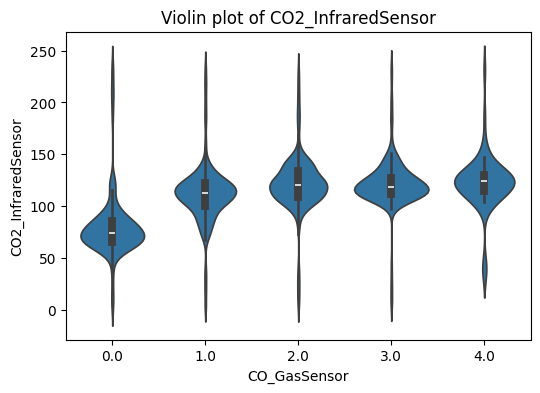

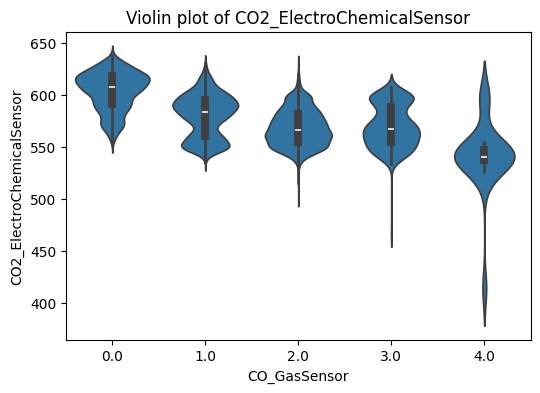

In [127]:
numerical_cols = [
    'CO2_InfraredSensor',
     'CO2_ElectroChemicalSensor', 
]

for x in numerical_cols:
    plt.figure(figsize=(6,4))  # create a new figure for each plot
    sns.violinplot(x='CO_GasSensor', y=x, data=df_clean)
    plt.title(f'Violin plot of {x}')  # optional: add a title
    plt.show()  # display the plot

^^ CO₂ infrared has a stronger relationship with CO_GasSensor than the electrochemical CO₂ sensor. where infrared shpws positive relationship and electro shows a more variable and complex relation with GasSensor

finding their difference can get sensor disagreement which unusual air conditions or even sensor inconsistency



CHECKING HVAC correlation

In [128]:
df_clean["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
1    1272
4    1267
5    1246
3    1244
2    1215
6    1165
Name: count, dtype: int64

In [ ]:
# Most common HVAC Operation Mode for each Time of Day
print(df_clean.groupby("Time of Day")["HVAC Operation Mode"].agg(lambda x: x.mode()[0]))
print(df_clean.groupby("CO2_GasSensor")["HVAC Operation Mode"].agg(lambda x: x.mode()[0]))
print(df_clean.groupby("Activity level")["HVAC Operation Mode"].agg(lambda x: x.mode()[0]))

Time of Day
1    6
2    1
3    1
4    3
Name: HVAC Operation Mode, dtype: int64

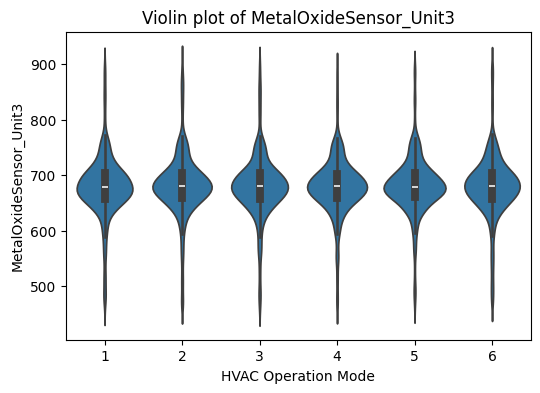

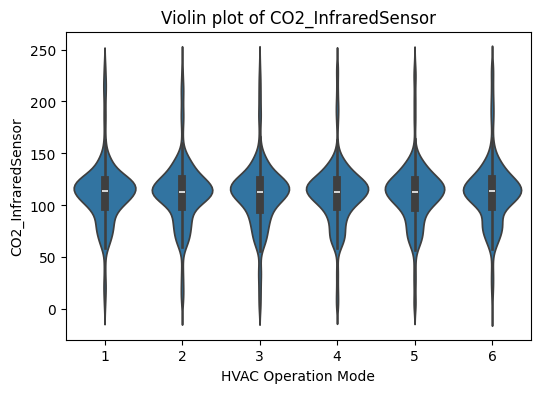

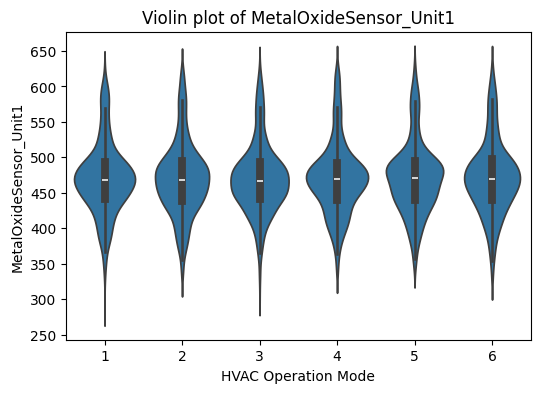

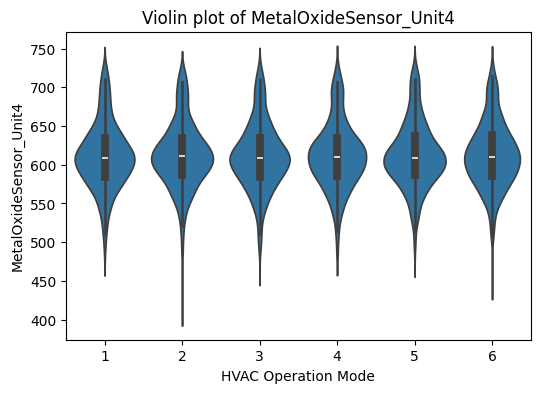

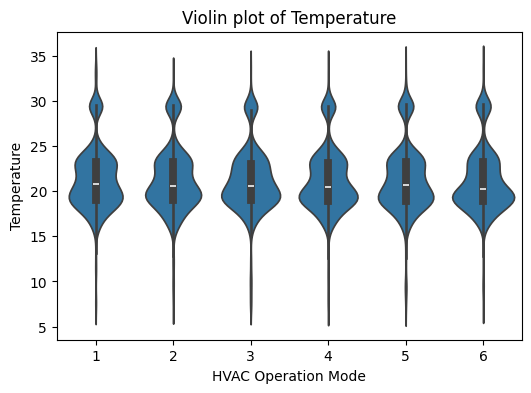

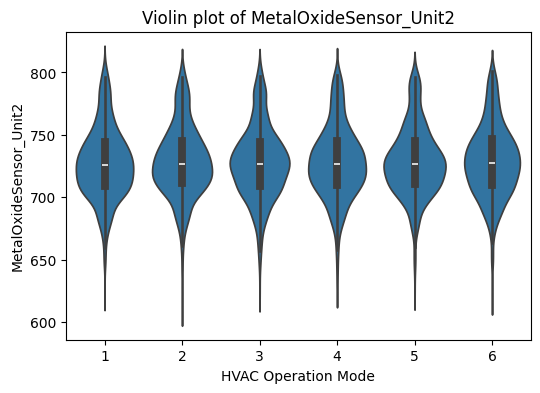

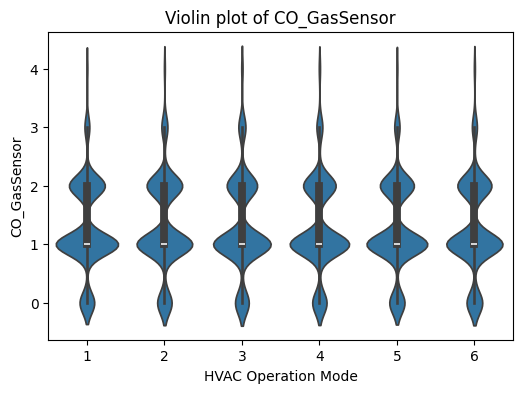

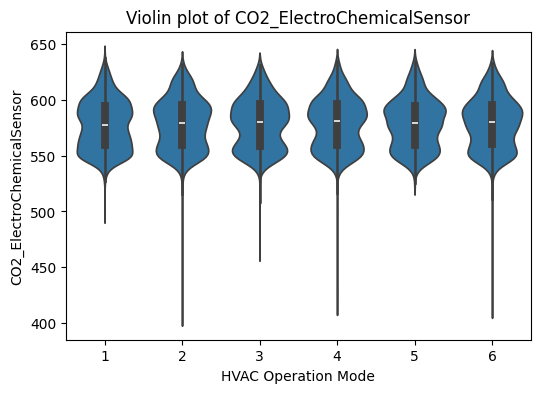

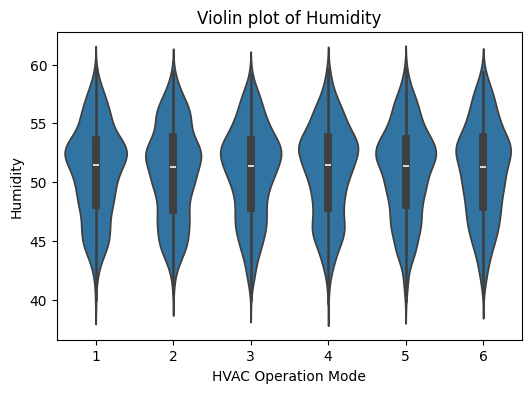

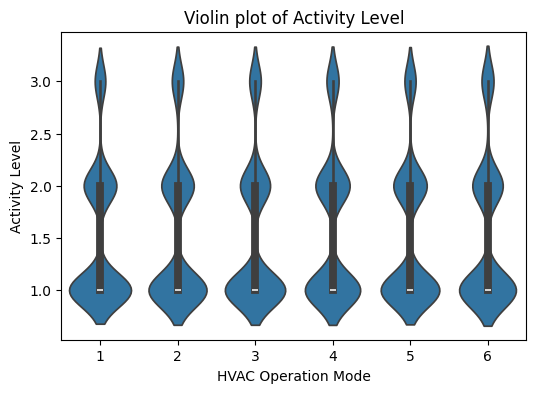

In [129]:
numerical_cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity', 'Activity Level'
]

for x in numerical_cols:
    plt.figure(figsize=(6,4))  # create a new figure for each plot
    sns.violinplot(x='HVAC Operation Mode', y=x, data=df_clean)
    plt.title(f'Violin plot of {x}')  # optional: add a title
    plt.show()  # display the plot

All readings follow similar if not same pattern including outliers. MO1, MO4 and ElectroSensor have outliers that shoot out more under some modes, 

In [130]:
from scipy import stats

numerical_cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity', 'Activity Level'
]

print("=== Kruskal-Wallis Test: HVAC Operation Mode vs Numerical Features ===\n")

results = []
for col in numerical_cols:
    # Group each numerical column by HVAC mode
    groups = [group[col].dropna().values for _, group in df_clean.groupby('HVAC Operation Mode')]
    stat, p = stats.kruskal(*groups)
    results.append({'Feature': col, 'H-Statistic': round(stat, 4), 'p-value': round(p, 4)})

results_df = pd.DataFrame(results).sort_values('p-value')
print(results_df)

=== Kruskal-Wallis Test: HVAC Operation Mode vs Numerical Features ===

                     Feature  H-Statistic  p-value
9             Activity Level       7.2159   0.2051
4                Temperature       6.4795   0.2623
7  CO2_ElectroChemicalSensor       4.7528   0.4468
5     MetalOxideSensor_Unit2       4.0574   0.5412
6               CO_GasSensor       2.5985   0.7616
0     MetalOxideSensor_Unit3       1.7404   0.8838
2     MetalOxideSensor_Unit1       1.7348   0.8845
3     MetalOxideSensor_Unit4       1.7176   0.8867
1         CO2_InfraredSensor       1.2107   0.9438
8                   Humidity       0.7651   0.9792


Kruskal-Wallis Test: used to compare three or more independent groups to determine if there are statistically significant differences between them

"Do sensor readings differ significantly between HVAC modes?"

H-statistic is how much the distributions differ across groups. higher means how much change due to HVAC mode diff
p-value is the probability that the observed difference between groups happened by random chance. lower btr
    
    Temperature is most affected by HVAC and Activity Level, high p value indicates there still isnt much differences between modes even for those two

     p ≥ 0.05 → fail to reject the null (no evidence of difference)


Feature importance

In [131]:
from sklearn.feature_selection import mutual_info_classif

X = df_clean[numerical_cols]
y = df_clean['HVAC Operation Mode'].astype(int)
mi = mutual_info_classif(X, y, random_state=42)

pd.Series(mi, index=X.columns).sort_values(ascending=False)

MetalOxideSensor_Unit3       0.045788
CO2_ElectroChemicalSensor    0.045590
MetalOxideSensor_Unit1       0.042760
MetalOxideSensor_Unit4       0.033711
MetalOxideSensor_Unit2       0.032885
CO2_InfraredSensor           0.026260
Temperature                  0.022716
Activity Level               0.001763
CO_GasSensor                 0.000000
Humidity                     0.000000
dtype: float64

MI is:

Non-linear, 
Non-parametric, 
Does not indicate positive or negative correlation

Results show weak to no correlation in all fields

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd

X = df_clean[numerical_cols]
y = df_clean['HVAC Operation Mode'].astype(int)

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Built-in feature importance
builtin_imp = pd.Series(rf.feature_importances_, index=X.columns).rename('Built-in Importance')

# Permutation importance
perm_result = permutation_importance(rf, X, y, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm_result.importances_mean, index=X.columns).rename('Permutation Importance')

# Combine
importance_df = pd.concat([builtin_imp, perm_imp], axis=1).sort_values('Built-in Importance', ascending=False)
print(importance_df)

                           Built-in Importance  Permutation Importance
MetalOxideSensor_Unit1                0.125757                0.056458
MetalOxideSensor_Unit4                0.123759                0.022689
CO2_ElectroChemicalSensor             0.123287                0.119638
CO2_InfraredSensor                    0.122150                0.042732
MetalOxideSensor_Unit3                0.121181                0.050223
MetalOxideSensor_Unit2                0.119136                0.031462
Humidity                              0.113464                0.037751
Temperature                           0.104897                0.058510
Activity Level                        0.024676                0.001431
CO_GasSensor                          0.021693                0.000000


forest has bias towards numbers/high unique values and 'repeat' columns like co2 and oxide sensor affects Importance.
Permutation reduces it. Temperature is most important, Co2 electro is 'better' than co2 infared. Metal Oxide 4, CO_Gas and Activity Level are Useless

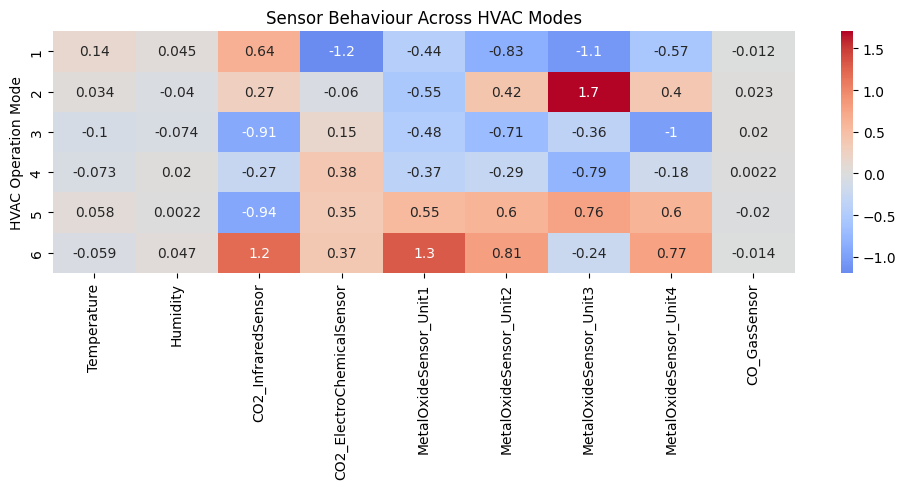

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define which sensors you want to compare
sensor_cols = [
    'Temperature',
    'Humidity',
    'CO2_InfraredSensor',
    'CO2_ElectroChemicalSensor',
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4',
    'CO_GasSensor'
]

# 2. Compute the mean of each sensor per HVAC mode
mode_means = df_clean.groupby("HVAC Operation Mode")[sensor_cols].mean()

# 3. Normalise — subtract the overall mean so heatmap shows
#    "above or below average" per mode, not raw values
mode_effect = mode_means - mode_means.mean()

# 4. Plot
plt.figure(figsize=(10, 5))
sns.heatmap(
    mode_effect,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Sensor Behaviour Across HVAC Modes")
plt.tight_layout()
plt.show()

In [160]:
print# Show rows where 'HVAC Operation Mode' contains 'HVAC'
df_legend[df_legend['Column'].str.contains("HVAC", na=False)]


,Column,Original_Value,Encoded_Value
4,HVAC Operation Mode,cooling_active,1
5,HVAC Operation Mode,eco_mode,2
6,HVAC Operation Mode,heating_active,3
7,HVAC Operation Mode,maintenance_mode,4
8,HVAC Operation Mode,off,5
9,HVAC Operation Mode,ventilation_only,6


'ECO', 'Off' and 'ventilation only' has higher sensor values, 'off' mode results in less CO, CO2 and metal oxide than ECo but less than ventilation

CHECKING ACTIVITY LEVEL

In [133]:
df_clean.groupby("Activity Level")[numerical_cols].median()

,MetalOxideSensor_Unit3,CO2_InfraredSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit4,Temperature,MetalOxideSensor_Unit2,CO_GasSensor,CO2_ElectroChemicalSensor,Humidity,Activity Level
Activity Level,,,,,,,,,,
1,666.70,117.50,458.00,594.30,21.50,714.7,1.0,568.7,51.80,1.0
2,698.00,104.80,486.30,629.95,19.45,740.8,1.0,590.0,50.20,2.0
3,690.75,110.75,473.35,619.35,19.70,734.7,1.0,586.9,51.75,3.0


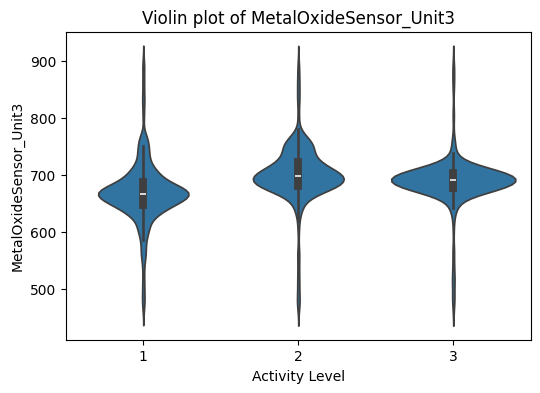

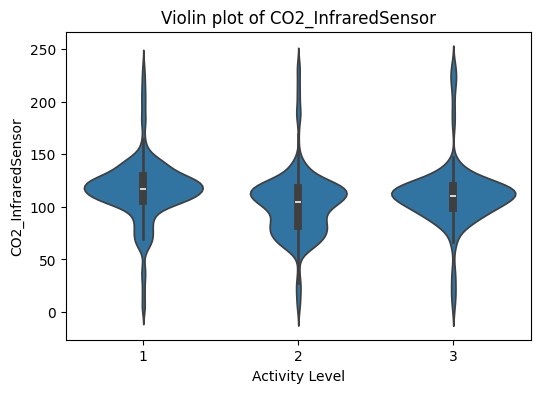

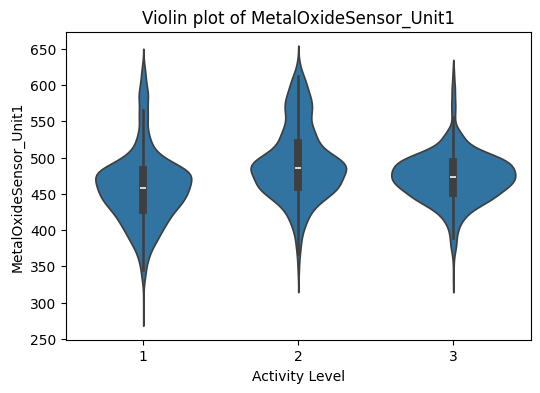

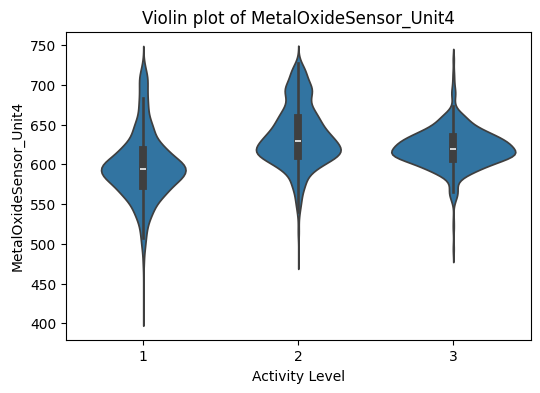

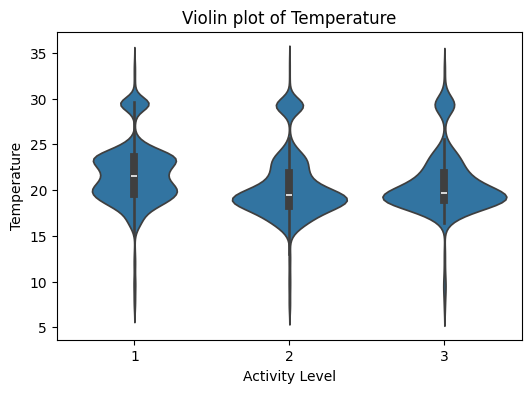

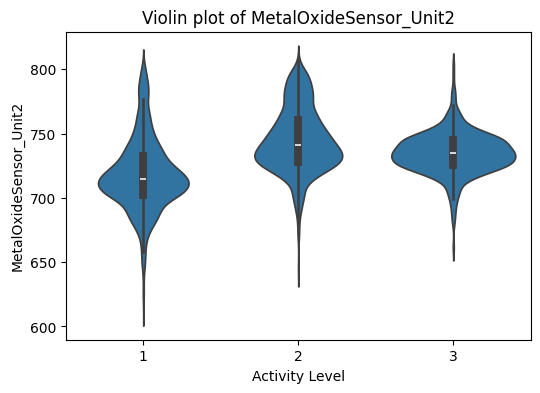

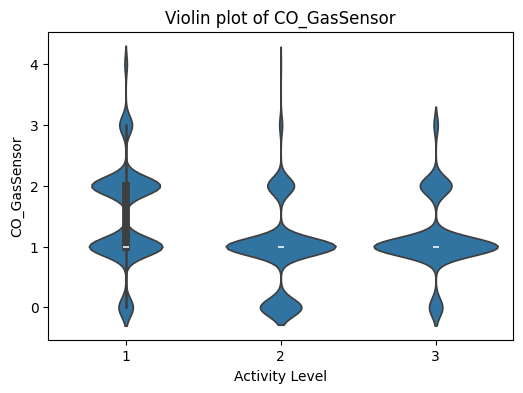

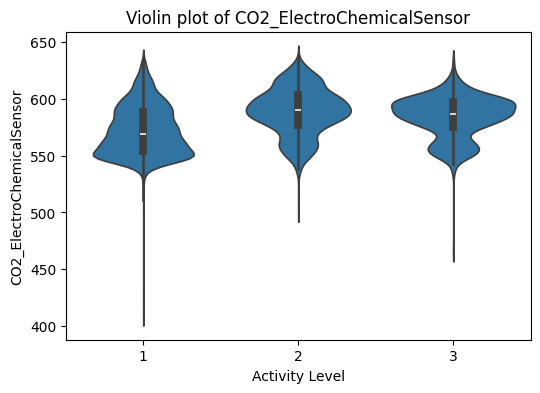

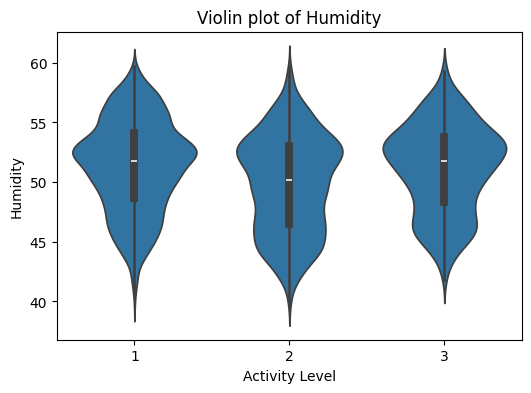

In [134]:
numerical_cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity', 
]

for x in numerical_cols:
    plt.figure(figsize=(6,4))  # create a new figure for each plot
    sns.violinplot(x='Activity Level', y=x, data=df_clean)
    plt.title(f'Violin plot of {x}')  # optional: add a title
    plt.show()  # display the plot

MO sensors seem to have similar pattern between activity levels where their 50% is around the same but 3 is more condensed on that point, 2 leans towards the right(higher value) and one stretches between left and right evenly while its 50% stands slightly below the others.

In [135]:

print("=== Kruskal-Wallis Test: Activity Level vs Numerical Features ===\n")
numerical_cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity'
]
results = []
for col in numerical_cols:

    groups = [group[col].dropna().values for _, group in df_clean.groupby('Activity Level')]
    stat, p = stats.kruskal(*groups)
    results.append({'Feature': col, 'H-Statistic': round(stat, 4), 'p-value': round(p, 4)})

results_df = pd.DataFrame(results).sort_values('p-value')
print(results_df)


=== Kruskal-Wallis Test: Activity Level vs Numerical Features ===

                     Feature  H-Statistic  p-value
0     MetalOxideSensor_Unit3    1201.7574      0.0
1         CO2_InfraredSensor     568.5089      0.0
2     MetalOxideSensor_Unit1     733.9073      0.0
3     MetalOxideSensor_Unit4    1470.3808      0.0
4                Temperature     496.5099      0.0
5     MetalOxideSensor_Unit2    1600.6920      0.0
6               CO_GasSensor     820.4966      0.0
7  CO2_ElectroChemicalSensor     946.8608      0.0
8                   Humidity     203.4737      0.0


Every numerical sensor feature differs significantly across Activity Level groups (all p-values ≈ 0). This means the distributions of these sensor readings change as room activity changes. 

    Shows statistically significant differences between Activity Levels

/tmp/ipykernel_8377/2286352540.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity Level', y=top_feature, data=df_clean, palette='Set2')


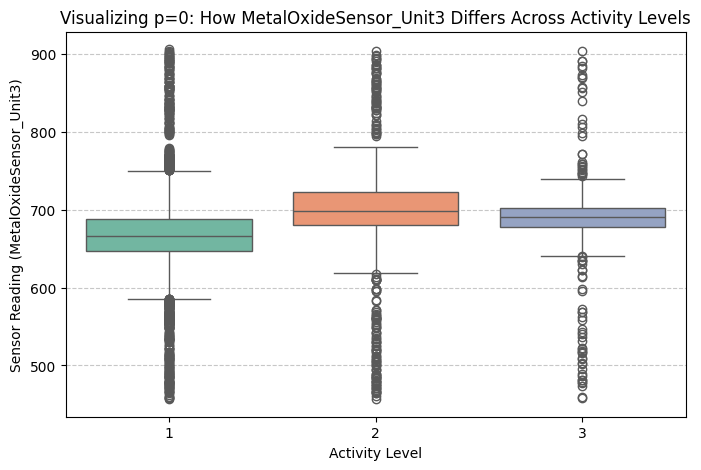

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pick the feature that had the highest H-Statistic in your results_df
top_feature = results_df.iloc[0]['Feature']

plt.figure(figsize=(8, 5))
sns.boxplot(x='Activity Level', y=top_feature, data=df_clean, palette='Set2')
plt.title(f"Visualizing p=0: How {top_feature} Differs Across Activity Levels")
plt.ylabel(f"Sensor Reading ({top_feature})")
plt.xlabel("Activity Level")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

^^ MO3 also had the most outliers

Activity level and MO3 is not directly proportional

outliers are evenly spread across activity levels but becomes more spread out, suggesing more eratic fluctuations as activity rises

Check Time of Day

In [137]:
df_clean['Time of Day'].value_counts()

Time of Day
2    1921
3    1849
1    1822
4    1817
Name: count, dtype: int64

In [138]:

print("=== Kruskal-Wallis Test: time vs Numerical Features ===\n")
numerical_cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity'
]
results = []
for col in numerical_cols:

    groups = [group[col].dropna().values for _, group in df_clean.groupby('Time of Day')]
    stat, p = stats.kruskal(*groups)
    results.append({'Feature': col, 'H-Statistic': round(stat, 4), 'p-value': round(p, 4)})

results_df = pd.DataFrame(results).sort_values('p-value')
print(results_df)


=== Kruskal-Wallis Test: time vs Numerical Features ===

                     Feature  H-Statistic  p-value
0     MetalOxideSensor_Unit3    1126.0972      0.0
1         CO2_InfraredSensor    1140.3023      0.0
2     MetalOxideSensor_Unit1    1721.3683      0.0
3     MetalOxideSensor_Unit4    1615.8901      0.0
4                Temperature    2468.5101      0.0
5     MetalOxideSensor_Unit2    1640.9736      0.0
6               CO_GasSensor     940.6645      0.0
7  CO2_ElectroChemicalSensor     323.2052      0.0
8                   Humidity    1466.7144      0.0


Every numerical sensor feature differs significantly across Activity Level groups (high hvalue, all p-values ≈ 0). This means the distributions of these sensor readings change as time changes. 

    Shows statistically significant differences between Time of Day 

/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

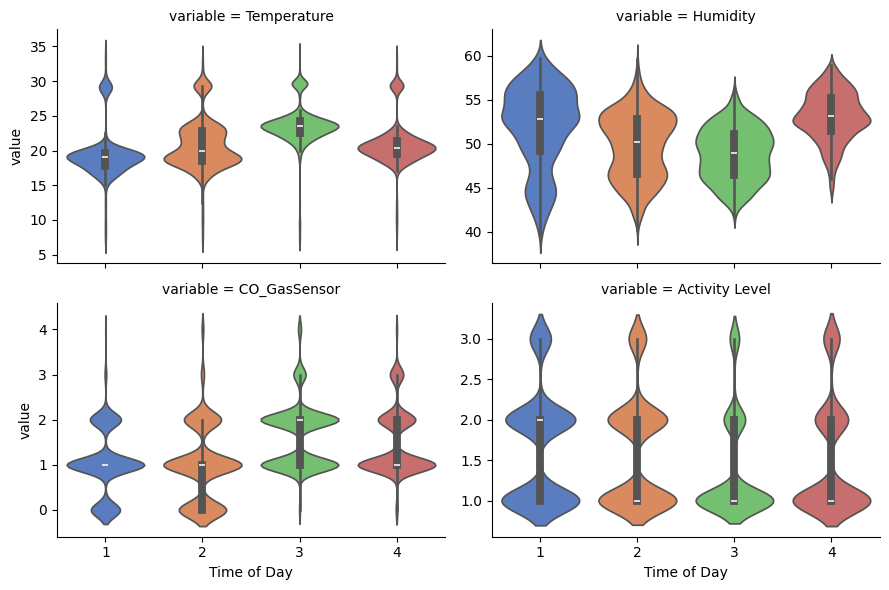

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt



# Melt the dataframe to make it compatible with FacetGrid
df_melt = df_clean.melt(id_vars=['Time of Day'], value_vars=['Temperature', 'Humidity', 'CO_GasSensor','Activity Level'])

# Create the faceted violin plot
g = sns.FacetGrid(df_melt, col="variable", col_wrap=2, sharey=False, aspect=1.5)
g.map(sns.violinplot, "Time of Day", "value", palette="muted")

^^Temperature seems to be inverse of humidity, sensor could be detecting relative humidity 


CO builds through the day, peaking at Time 3, consistent with occupancy/activity patterns — aligns with the Activity Level plot, increased CO levels might have caused less activity in the evening

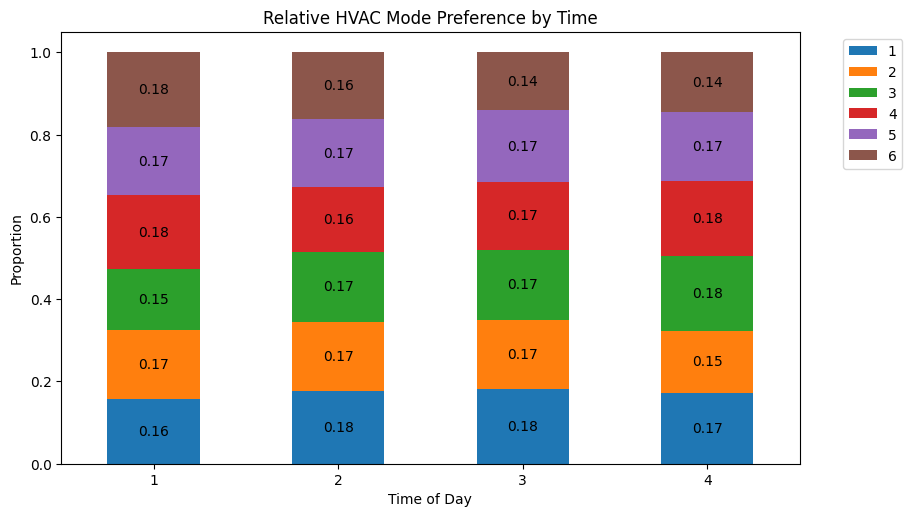

In [140]:
import matplotlib.pyplot as plt

mode_time_pct = pd.crosstab(
    df_clean["Time of Day"],
    df_clean["HVAC Operation Mode"],
    normalize="index"
)

ax = mode_time_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

# Add labels inside each stacked bar
for container in ax.containers:
    # Loop through each bar segment
    ax.bar_label(container, fmt="%.2f", label_type="center")

# Adjust layout to prevent overlap
plt.tight_layout()

# Place legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel("Proportion")
plt.title("Relative HVAC Mode Preference by Time")
plt.xticks(rotation=0)
plt.show()


No apprant change in HVAC operation  between times

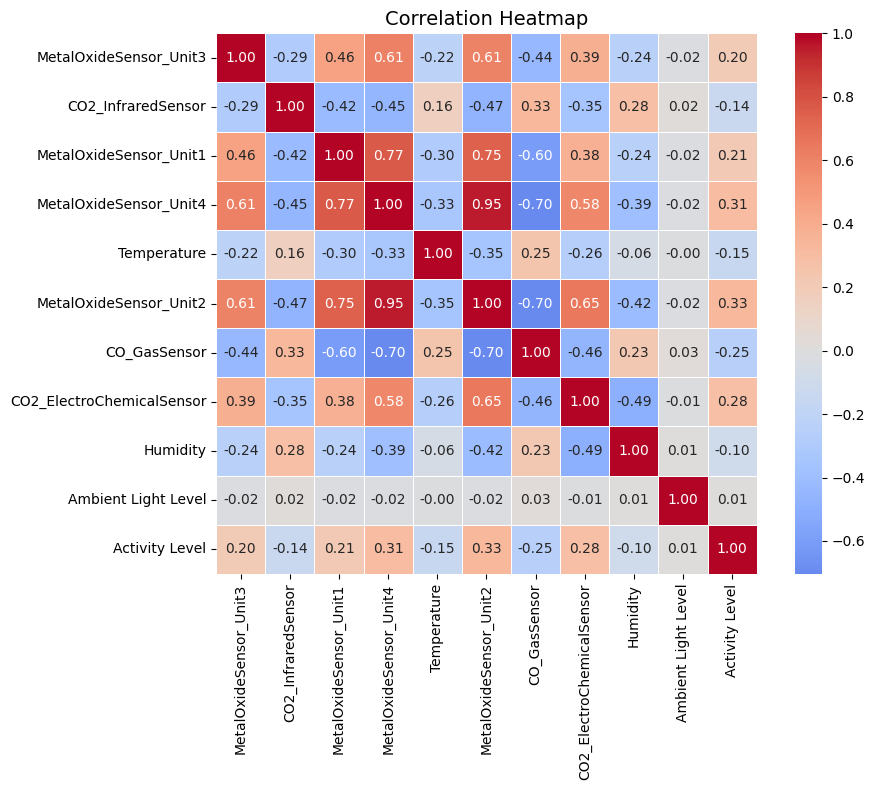

In [141]:
cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity','Ambient Light Level', 'Activity Level'
]


# Compute correlation matrix
corr = df_clean[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,      # show correlation values inside cells
            cmap='coolwarm', # color scheme (red=negative, blue=positive)
            center=0,        # center colormap at zero
            square=True,     # square cells
            linewidths=0.5,  # grid lines
            fmt='.2f')       # format for annotations (2 decimals)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [142]:
cols = [
    'Temperature',
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity','Ambient Light Level', 'Activity Level'
]
df_clean.groupby("Time of Day")[cols].mean()

,Temperature,MetalOxideSensor_Unit3,CO2_InfraredSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit4,MetalOxideSensor_Unit2,CO_GasSensor,CO2_ElectroChemicalSensor,Humidity,Ambient Light Level,Activity Level
Time of Day,,,,,,,,,,,
1,19.501597,697.987157,104.861910,500.327278,635.545499,744.101874,1.042261,583.040999,51.881723,3.823271,1.663557
2,20.838178,693.298594,100.872670,488.007288,628.517699,739.531330,1.002603,584.020927,49.797657,3.857887,1.609578
3,23.644575,660.935965,119.712655,443.880692,587.283018,711.186618,1.643591,573.549648,48.826609,3.846944,1.369930
4,20.931580,669.907595,120.324051,450.448927,597.121244,718.470218,1.498074,573.911998,53.102532,3.925151,1.515135


^^

Elderly tend to move around a little but less in the evening, this is reflected in co2 sensor as well

Light level appears to be consistently high while temperature is low

In [145]:
df_clean.describe()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
count,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000,7409.000000
mean,2.494129,21.232764,50.878324,111.325725,578.687583,470.813794,728.416486,680.638669,612.255635,1.293832,5427.409637,3.471724,3.863139,1.539884
std,1.110158,3.646833,3.965921,31.607234,22.572915,51.187083,28.816795,55.729946,42.977718,0.785544,2598.238228,1.699254,1.134884,0.687797
min,1.000000,6.900000,39.700000,-0.000000,408.600000,286.800000,611.200000,456.700000,412.800000,0.000000,1374.000000,1.000000,1.000000,1.000000
25%,2.000000,19.000000,47.900000,97.700000,559.400000,440.100000,709.700000,658.600000,586.000000,1.000000,3074.000000,2.000000,3.000000,1.000000
50%,2.000000,20.500000,51.400000,113.300000,579.400000,468.600000,726.700000,680.100000,609.600000,1.000000,5214.000000,3.000000,4.000000,1.000000
75%,3.000000,23.200000,53.700000,124.900000,595.400000,494.700000,745.100000,704.000000,635.600000,2.000000,7395.000000,5.000000,5.000000,2.000000
max,4.000000,34.300000,59.700000,237.900000,637.900000,632.900000,807.700000,905.800000,733.100000,4.000000,9658.000000,6.000000,5.000000,3.000000


In [149]:
cols = [
    'Temperature','Humidity', 'HVAC Operation Mode',
    'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'MetalOxideSensor_Unit2','CO2_InfraredSensor', 
     'CO2_ElectroChemicalSensor', 'Ambient Light Level', 'Activity Level'
]
df_clean.groupby("CO_GasSensor")[cols].mean()

,Temperature,Humidity,HVAC Operation Mode,MetalOxideSensor_Unit3,MetalOxideSensor_Unit1,MetalOxideSensor_Unit4,MetalOxideSensor_Unit2,CO2_InfraredSensor,CO2_ElectroChemicalSensor,Ambient Light Level,Activity Level
CO_GasSensor,,,,,,,,,,,
0.0,19.063795,47.556604,3.529350,732.086478,547.544759,678.383648,772.047814,80.918449,603.759853,3.808176,1.694969
1.0,21.114619,51.248182,3.467172,685.939786,473.793696,617.597960,732.480920,111.882396,579.788857,3.857965,1.681664
2.0,22.159932,51.547019,3.457442,657.540692,440.971234,584.327993,709.336855,121.523760,568.439873,3.883933,1.295403
3.0,22.194960,51.645822,3.444744,645.329111,427.556065,568.587332,697.902503,121.471968,570.028841,3.865229,1.207547
4.0,23.215625,50.895313,3.531250,594.681250,424.239062,519.257812,667.104241,122.435937,541.148438,4.265625,1.078125


In [143]:

df_legend.to_csv('df_legend.csv', index=False)

df_clean.to_csv('df_clean.csv', index=False)